# Project: Exploratory Data Analysis (EDA) on Titanic Dataset



## Project Objective



The Titanic dataset contains passenger information from the Titanic disaster. The goal is to explore the data, identify patterns, handle missing values, and generate insights using data analysis and visualization techniques.

## Step 1: Import Required Libraries

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Style settings
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load Dataset

In [2]:
# Load dataset from Seaborn

df = sns.load_dataset('titanic')

# Display first few rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 3: Dataset Overview

In [3]:
# Shape of dataset
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (891, 15)

Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


## Step 4: Basic Information

In [4]:
# Dataset summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Step 5: Statistical Summary

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### For categorical columns:

In [6]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


## Step 6: Missing Values Analysis

In [7]:
# Check missing values

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


### Visualizing Missing Values

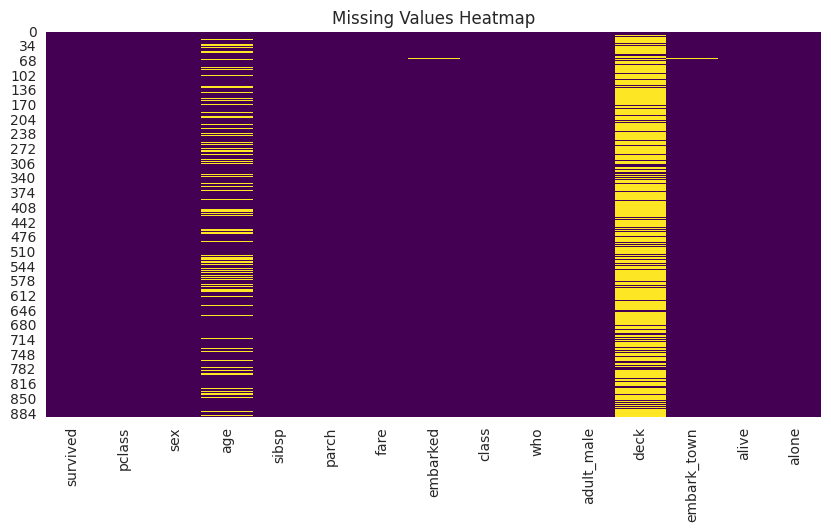

In [8]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

## Step 7: Handling Missing Values

In [9]:
# Fill age with median

df['age'] = df['age'].fillna(df['age'].median())

# Fill embarked with mode

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop deck because of too many missing values

df = df.drop('deck', axis=1)

# Verify
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


## Step 8: Univariate Analysis

### Age Distribution

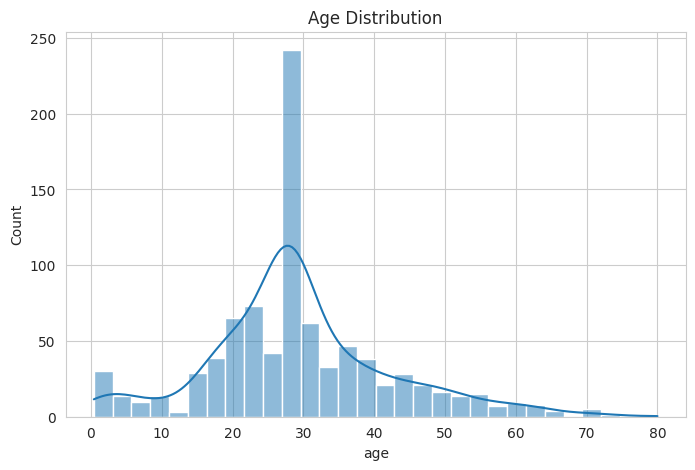

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

### Fare Distribution

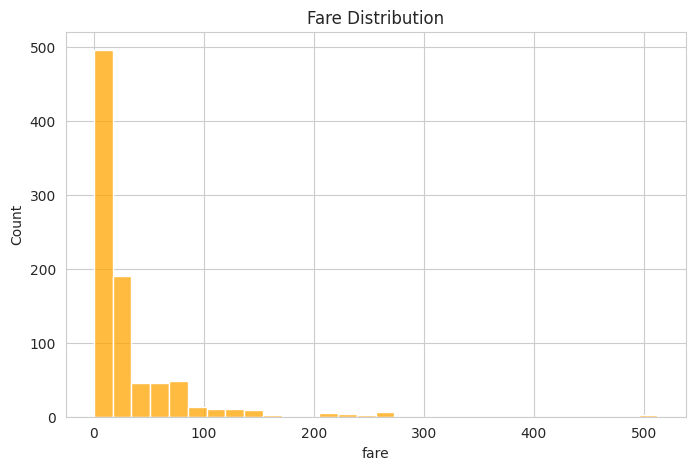

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare'], bins=30, color='orange')
plt.title("Fare Distribution")
plt.show()

### Passenger Class Distribution

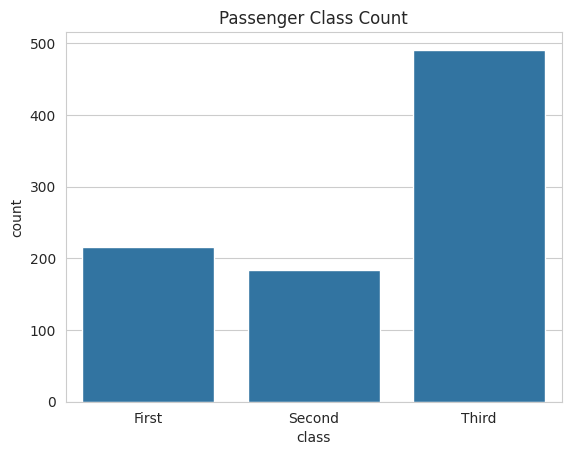

In [12]:
sns.countplot(x='class', data=df)
plt.title("Passenger Class Count")
plt.show()

## Step 9: Survival Analysis

### Overall Survival Rate

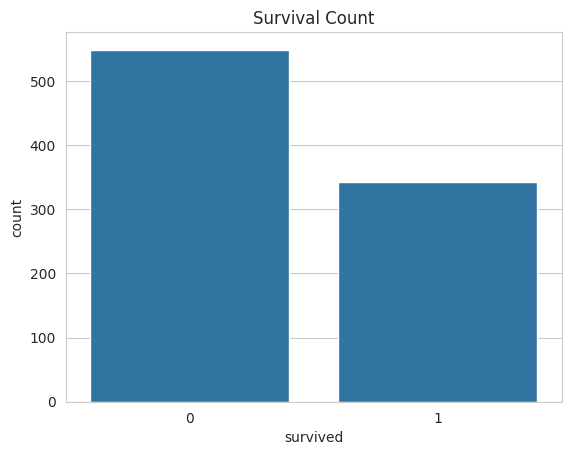

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [13]:
sns.countplot(x='survived', data=df)

plt.title("Survival Count")
plt.show()

print(df['survived'].value_counts(normalize=True)*100)

## Step 10: Bivariate Analysis

### Survival by Gender

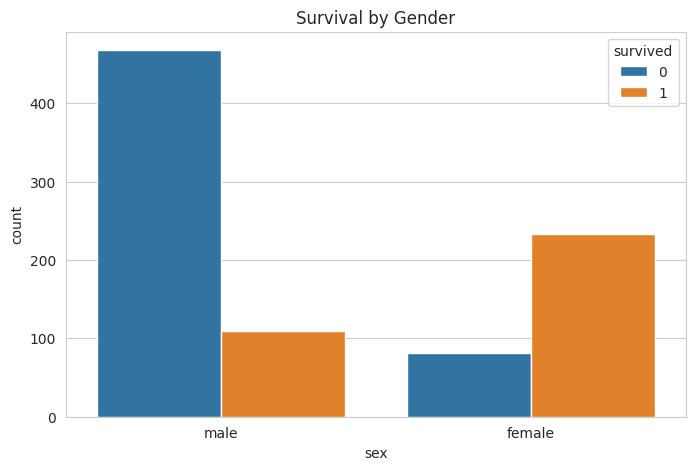

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='survived', data=df)

plt.title("Survival by Gender")
plt.show()

### Survival by Passenger Class

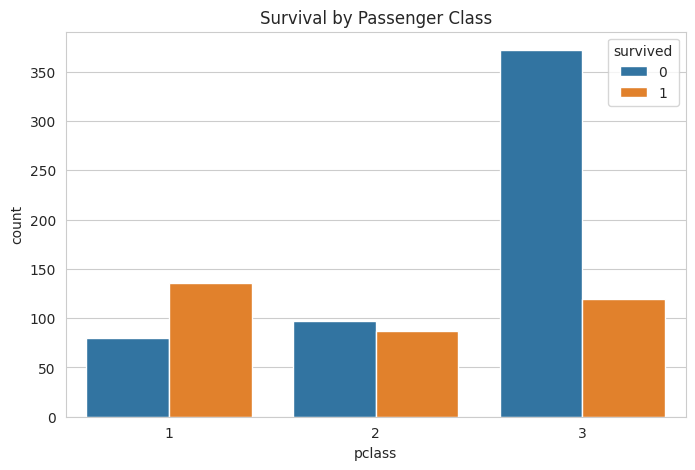

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='pclass', hue='survived', data=df)

plt.title("Survival by Passenger Class")
plt.show()

### Age vs Fare

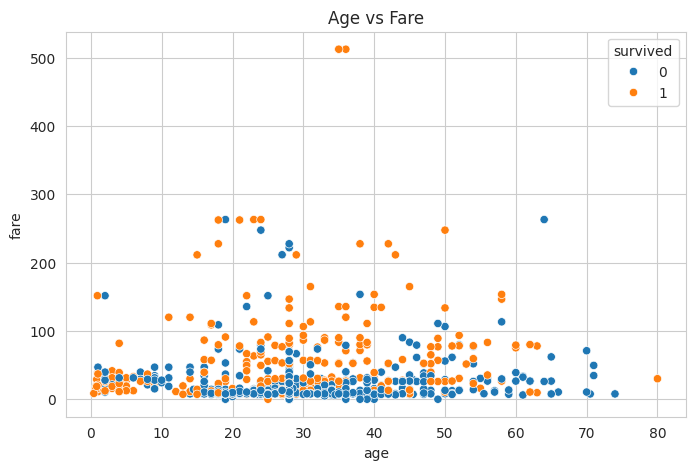

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='age',
    y='fare',
    hue='survived',
    data=df
)

plt.title("Age vs Fare")
plt.show()

## Step 11: Multivariate Analysis

### Pairplot

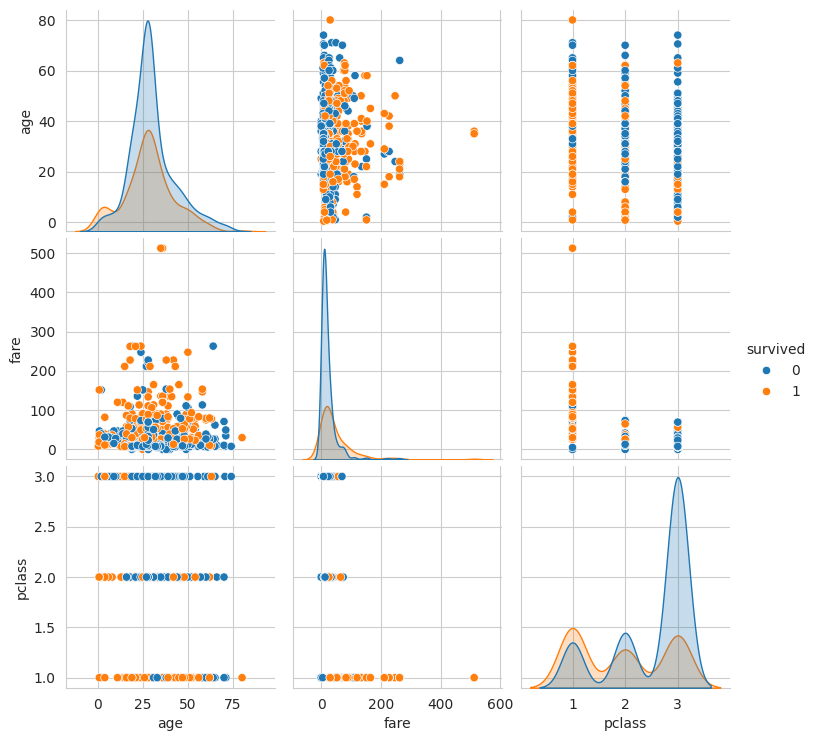

In [17]:
sns.pairplot(
    df[['survived','age','fare','pclass']],
    hue='survived'
)

plt.show()

## Step 12: Correlation Analysis

### Correlation Matrix

In [18]:
numeric_df = df.select_dtypes(include=[int, float])

corr_matrix = numeric_df.corr()

corr_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


### Heatmap

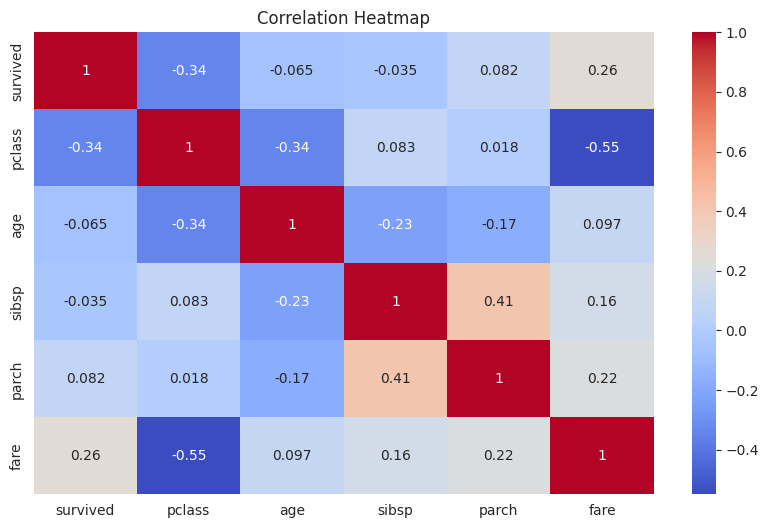

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Step 13: Grouping and Aggregation

### Average Fare by Class

In [20]:
df.groupby('class')['fare'].mean().sort_values(ascending=False)

/tmp/ipykernel_11940/2789473555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('class')['fare'].mean().sort_values(ascending=False)


,fare
class,
First,84.154687
Second,20.662183
Third,13.675550


### Average Age by Gender

In [21]:
df.groupby('sex')['age'].mean()

,age
sex,
female,27.929936
male,30.140676


### Survival Rate by Class

In [22]:
df.groupby('class')['survived'].mean()*100

/tmp/ipykernel_11940/2657065733.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('class')['survived'].mean()*100


,survived
class,
First,62.962963
Second,47.282609
Third,24.236253


## Step 14: Feature Relationships

### Boxplot

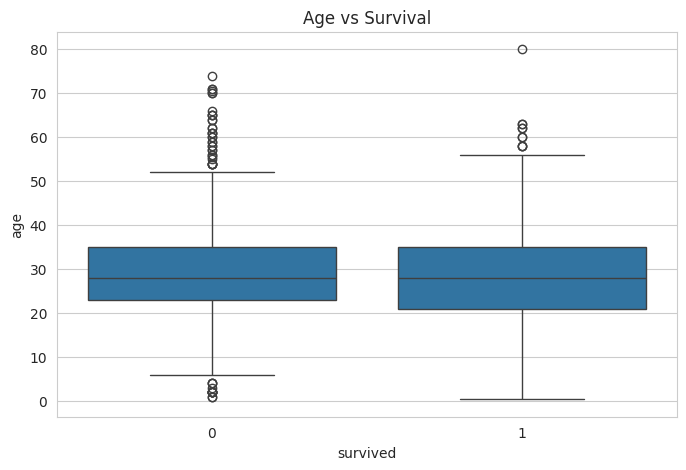

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='survived',
    y='age',
    data=df
)

plt.title("Age vs Survival")
plt.show()

### Violin Plot

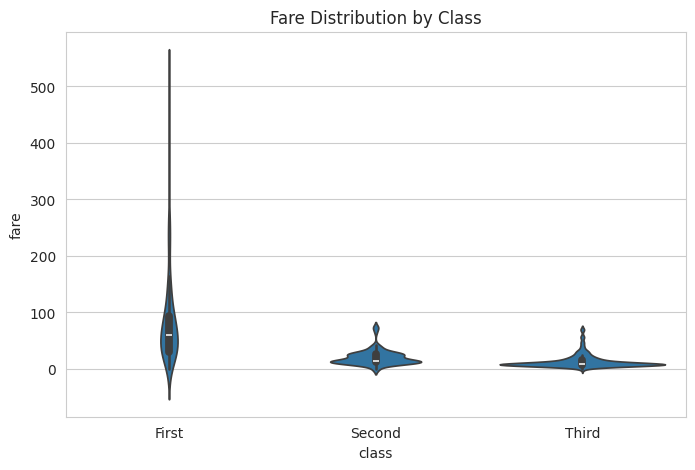

In [24]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='class',
    y='fare',
    data=df
)

plt.title("Fare Distribution by Class")
plt.show()

## Step 15: Key Insights

1. Female passengers had significantly higher survival rates.
2. First-class passengers were more likely to survive.
3. Younger passengers showed slightly better survival chances.
4. Fare and passenger class are strongly related.
5. Higher ticket fares generally corresponded to higher survival rates.

## Conclusion:

The EDA process revealed several important patterns in the Titanic dataset.
Passenger gender and class were major factors affecting survival.
Data visualization helped uncover trends that would be difficult to identify
from raw tables alone.

This project demonstrates:

✔ Data Cleaning

✔ Missing Value Treatment

✔ Statistical Analysis

✔ Data Visualization

✔ Correlation Analysis

✔ Business Insight Generation